# CSE 4095 — Class 3: Regression and Model Error
Use AI to help write unfamiliar code, but verify and explain each modeling decision.

1. Why is this a regression problem?
- This is a regression problem because it involves predicting exam_score, a numerical value based on Input Features

2. How is this different from the Class 2 classification problem?
- Instead of predicting which students had high_exam scores or not using a 80 >= condition, we are instead predicting the exact numerical exam_score based on input features

3. What information is lost when we convert exam_score into only Yes or No?
- We lose the exact numerical score that a student gets after taking the exam

4. What kind of output should a regression model produce
- In our case, a regression should output a predicted numerical value for a student's exam_score and checking how close that value ended being to the actual exam_score

## 1. Load and inspect the dataset
Upload `class1_student_habits.csv`, load it as `df`, and inspect `exam_score`.

0     64.6
1     81.5
2     92.0
3    100.0
4     68.5
Name: exam_score, dtype: float64

Data type: float64
Missing values: 0

Summary statistics:
count    250.000000
mean      77.159600
std       10.330499
min       51.400000
25%       69.500000
50%       76.950000
75%       84.975000
max      100.000000
Name: exam_score, dtype: float64


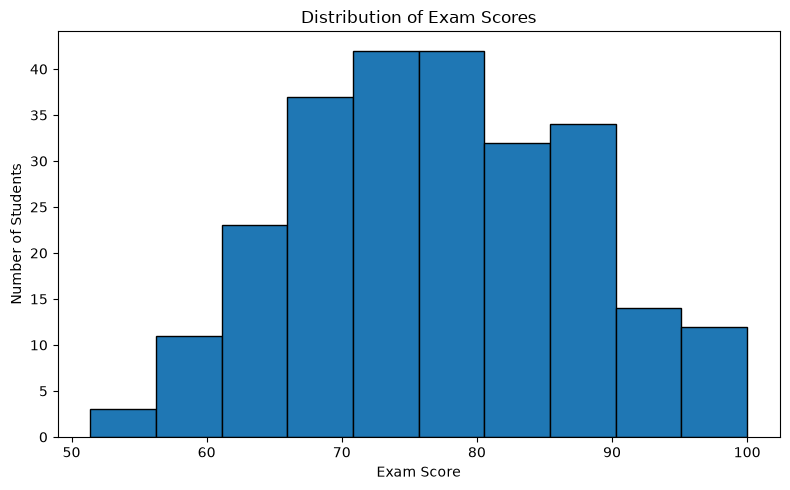

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Preserve "None" as a category; treat blank fields as missing.
df = pd.read_csv(
    "class1_student_habits.csv",
    keep_default_na=False,
    na_values=[""]
)

# Inspect exam scores.
print(df["exam_score"].head())
print("\nData type:", df["exam_score"].dtype)
print("Missing values:", df["exam_score"].isna().sum())
print("\nSummary statistics:")
print(df["exam_score"].describe())

# Plot the distribution after loading the data.
plt.figure(figsize=(8, 5))
plt.hist(df["exam_score"].dropna(), bins=10, edgecolor="black")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
plt.tight_layout()
plt.show()

1. Describe the distribution of exam score
- There are about 250 exam scores, the mean of all exam scores is 77, while the std is about 10, the lowest score for an exam was 51 and the max score was 100.

2. Are there unusually low or high values?
- Not really, all of these exam_scores seem pretty normal for a student, though one student got a perfect 100

## 2. Explore one relationship
Plot `study_hours_per_week` versus `exam_score` and describe what you observe.

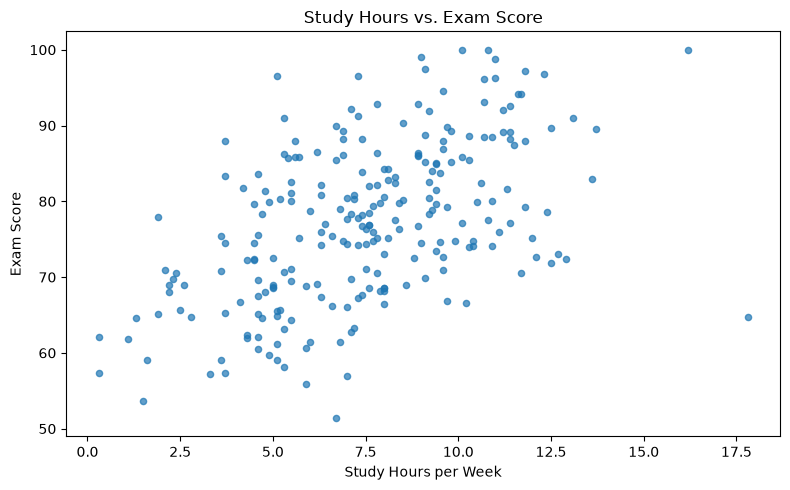

In [6]:
# TODO: create the scatter plot
import matplotlib.pyplot as plt

df.plot.scatter(
    x="study_hours_per_week",
    y="exam_score",
    figsize=(8, 5),
    alpha=0.7
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.tight_layout()
plt.show()

1. Does there appear to be a relationship?
- There seems to be a linear correlation between the two variables. In general higher study hours are associated with higher exam scores

2. Is the relationship positive or negative?
- The relationship is positive

3. Does it appear approximately linear?
- If I were to draw a line, the points would follow the same pattern as the line

4. Are there students who do not follow the general pattern?
- There are a few outlier students, one example of a student studyng for 17.5 hours in a week, but scoring between 60-70 instead of higher like the general trend suggests

## 3. Define X and y
Start without `quiz_average`. Explain why `student_id` is excluded.

In [7]:
# TODO: define feature columns, X, and y
feature_columns = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_rate",
    "practice_problems_per_week",
    "prior_programming_experience",
    "study_group",
    "commute_minutes"
]

X = df[feature_columns]
y = df["exam_score"]

print("Feature dimensions:", X.shape)
print("Target dimensions:", y.shape)

Feature dimensions: (250, 7)
Target dimensions: (250,)


## 4. Train/test split and preprocessing
Use an 80/20 split and a pipeline that handles missing values and categorical variables.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

numeric_features = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_rate",
    "practice_problems_per_week",
    "commute_minutes"
]

categorical_features = [
    "prior_programming_experience",
    "study_group"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 200
Testing samples: 50


1. What is the training set used for?
- Its to give a model some sample data to read over so it recognize patterns in regards to what input features impact exam_score

2. What is the test set used for?
- After being trained, the testing set is there to see how the model deals with new unseen data

3. Why should the model not be train using the test set?
- The test set only has a small portion of data in comparison to the training set, not giving the model enough data will impact its overall performance

4. Why should different experiments use the same split when we want to compare them fairly?
- Its because it gives all models the same amount of training and test data, so when it's time to perform, all models are given equal standing in terms of practice

1. Why do we handle numerical and categorical variables differently?
- For numerical features, the median is used to replaced missing values because it is less affected by extreme values than the mean
- For categorical features, string titles do no have a numerical median, so instead we use the most frequent category from the training set or replace missing values with a "Unknown category"

2. What does StandardScaler do?
- Puts numerical features on a comparable scale by transforming each value

3. What does one-hot encoding do?
- Converts categories into numerical columns that a model can use

4. Why should preprocessing be learned from the training data rather than the entire dataset?
- We do this to prevent data leakage, imputations and scaling learn values such as medians, mean,s and standard eviations, using the whole set would let info from the test set influence training, making the evaluation less trustworthy

## 5. Mean baseline
Predict the training-set mean for every test case and calculate baseline MAE.

In [9]:
# TODO: calculate mean baseline and MAE
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the mean using training scores only.
training_mean = y_train.mean()

# Predict that same score for every test student.
baseline_predictions = np.full(len(y_test), training_mean)

mse = mean_squared_error(y_test, baseline_predictions)

baseline_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, baseline_predictions)],
    "MSE": [mse],
    "RMSE": [np.sqrt(mse)],
    "R²": [r2_score(y_test, baseline_predictions)]
}, index=["Mean baseline"])

print(f"Training mean exam score: {training_mean:.2f}")
display(baseline_metrics.round(3))

Training mean exam score: 77.73


,MAE,MSE,RMSE,R²
Mean baseline,7.659,96.08,9.802,-0.091


1. Why is this useful?
- This baseline serves to check whether my model actually improve on simple prediction that ignores all input features

## 6. Linear regression
Fit a preprocessing + LinearRegression pipeline using training data only.

In [10]:
# TODO: build, fit, and predict
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import pandas as pd

# Combine the existing preprocessor with Linear Regression.
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit preprocessing and regression using training data only.
model.fit(X_train, y_train)

# Predict exam scores for the test students.
y_pred = model.predict(X_test)

# Display the first 10 actual and predicted scores.
prediction_examples = pd.DataFrame({
    "Actual Exam Score": y_test.to_numpy(),
    "Predicted Exam Score": y_pred
})

display(prediction_examples.head(10).round(2))

,Actual Exam Score,Predicted Exam Score
0,72.5,78.10
1,68.0,68.38
2,78.3,81.98
3,84.0,86.97
4,69.0,67.19
5,74.8,75.35
6,69.1,65.49
7,71.5,73.74
8,70.5,78.09
9,79.4,76.29


1. What does .fit() do?
- .fit() trains the pipeline, it learns preprocessing values from X_train, then learns the regression coefficients and intercept that connect the features to exam scores in y_train

2. What does .predict() do?
- produces predicted exam scores, it apples the learned preprocessing and regression model to the test features. It does not retrain or use y_test

3. Why can predicted exam score contain deciamls even if the original scores are whole numbers?
- Regression calculates predictions using a mathematical formula with learned coefficients, which can be any numerical value, including decimals

## 7. Metrics
Calculate MAE, MSE, and R². Compare with the baseline.

In [11]:
# TODO: evaluate predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

model_mse = mean_squared_error(y_test, y_pred)

model_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred)],
    "MSE": [model_mse],
    "RMSE": [np.sqrt(model_mse)],
    "R²": [r2_score(y_test, y_pred)]
}, index=["Linear Regression"])

# Compare with the baseline calculated earlier.
comparison = pd.concat([baseline_metrics, model_metrics])
display(comparison.round(3))

,MAE,MSE,RMSE,R²
Mean baseline,7.659,96.080,9.802,-0.091
Linear Regression,5.774,69.698,8.349,0.209


1. Which metric is easiest to explain in terms of exam-score points?
- Mean Absolute Error seems like the easiest to explain because it is just the average error of margin of the predictions to the exam score

2. Why does MSE penalize large errors more heavily than MAE?
- It is because after squaring a value can potentially error values much more larger than MAE because it only takes the absolute value

3. Why might RMSE be easier to interpret than MSE?
- It is because that you are simply taking the root of MSE, which expresses the original units of the target

4. Did linear regression outperform the mean baseline?
- Linear regression did perform better on all four metrics, meaning input feature did provide useful predictive information

5. What does R^2 tell me?
- It measures the performance relative to predicting the mean

## 8. Prediction table
Create actual, predicted, residual, and absolute-residual columns.

In [12]:
# TODO: build prediction/error table


## 9. Actual vs. predicted plot
Add a perfect-prediction reference line.

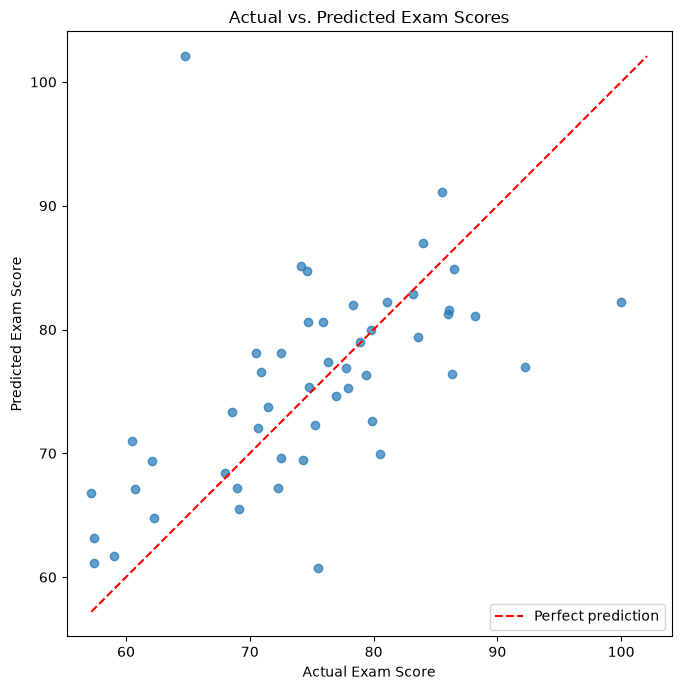

In [13]:
# TODO: actual vs predicted plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line: actual = predicted.
lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())
plt.plot([lower, upper], [lower, upper], "r--", label="Perfect prediction")

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs. Predicted Exam Scores")
plt.xlim(lower - 2, upper + 2)
plt.ylim(lower - 2, upper + 2)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

1. What would a perfect model look like on this graph?
- If all the exam_scores actually sat right on the perfect predictio line

2. Are most point close to the diagonal?
- The majority of points surround the perfect prediction line

3. Where does the model appear to make larger errors
- The model only seem to make larger errors when dealing with outlier exam_scores

## 10. Residual plot
Plot predicted values against residuals and add a horizontal zero line.

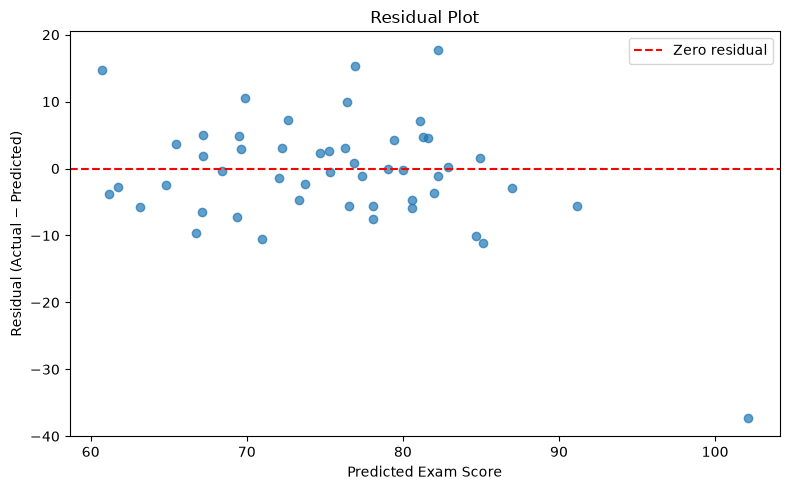

In [14]:
# TODO: residual plot
import matplotlib.pyplot as plt

# Residual = actual score - predicted score.
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--", label="Zero residual")

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot")
plt.legend()
plt.tight_layout()
plt.show()

1. What does a positive residual mean?
- It means the actual score is higher than predicted, meaning the model underpredicted

2. What does a negative residual mean?
- The actual score is lower than predicted, so the model overpredicted

3. What does a residual close to zero mean?
- The prediction is close to the actual score, indicating a small error

4. Do you see any pattern in the residual plot?
- Not really, the points are fairly dispersed, but they are relatively close to the zero residual line

## 11. Largest errors
Find and inspect the five largest absolute residuals.

In [15]:
# TODO: inspect largest errors
import pandas as pd

# Keep the test-set index so features match their actual scores.
error_table = X_test.copy()
error_table.insert(0, "student_id", df.loc[X_test.index, "student_id"])

error_table["actual_exam_score"] = y_test
error_table["predicted_exam_score"] = y_pred
error_table["residual"] = (
    error_table["actual_exam_score"] - error_table["predicted_exam_score"]
)
error_table["absolute_error"] = error_table["residual"].abs()

# Rank by error magnitude, including both over- and underpredictions.
largest_errors = error_table.nlargest(10, "absolute_error")

display(largest_errors[[
    "student_id",
    "actual_exam_score",
    "predicted_exam_score",
    "residual",
    "absolute_error",
    *feature_columns
]].round(2).reset_index(drop=True))

,student_id,actual_exam_score,predicted_exam_score,residual,absolute_error,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes
0,S174,64.8,102.09,-37.29,37.29,17.8,6.9,98.1,0,Strong,Yes,36
1,S109,100.0,82.25,17.75,17.75,10.1,7.3,91.6,25,None,Yes,0
2,S020,92.2,76.93,15.27,15.27,7.1,NaN,90.0,14,Some,Yes,24
3,S070,75.5,60.72,14.78,14.78,4.6,7.4,64.3,9,None,Yes,30
4,S241,74.1,85.16,-11.06,11.06,10.4,6.6,91.2,20,Some,No,0
5,S197,80.5,69.91,10.59,10.59,7.0,6.3,98.3,3,None,No,39
6,S016,60.5,70.98,-10.48,10.48,4.6,6.5,88.0,0,Strong,Yes,15
7,S223,74.6,84.70,-10.10,10.10,9.5,5.8,70.9,22,Strong,No,27
8,S068,86.3,76.42,9.88,9.88,5.3,6.2,98.2,22,Some,No,16
9,S160,57.2,66.77,-9.57,9.57,3.3,7.4,72.0,0,Strong,No,30


1. Student S174
- The model predicted 102.09, while the student's actual score being 64.8. The student had the highest study hours per week, a high attendance rate, and had a strong programming experience background, although the # of practice problems per week was set at 0. From this data, if the student had a large amount of study hours per week, then the model could've overpredicted the exam score

2. Student S109
- The model predicted 82.25, but the actual exam score was 100. The student had done a reasonable amount of time studying per week, had high attendance rates, and did a lot of practice problems per week. If their programming experience was practically nothing before this exam, then its reasonably to assume the model could've underpredicted their actual score considering their other stats

In [16]:
import pandas as pd

# Get feature names after imputation, scaling, and one-hot encoding.
transformed_features = (
    model.named_steps["preprocessor"].get_feature_names_out()
)

# Extract coefficients from the fitted Linear Regression model.
coefficients = model.named_steps["regressor"].coef_

coefficient_table = pd.DataFrame({
    "Transformed Feature": transformed_features,
    "Coefficient": coefficients
})

display(coefficient_table.round(4))

,Transformed Feature,Coefficient
0,numeric__study_hours_per_week,5.9334
1,numeric__sleep_hours_per_night,1.3291
2,numeric__attendance_rate,1.9763
3,numeric__practice_problems_per_week,3.1695
4,numeric__commute_minutes,0.5279
5,categorical__prior_programming_experience_None,-4.8672
6,categorical__prior_programming_experience_Some,-0.1925
7,categorical__prior_programming_experience_Strong,5.0597
8,categorical__study_group_No,0.1205
9,categorical__study_group_Yes,-0.1205


1. Which features have positive coefficients?
- study_hours_per_week, sleep_hours_per_night, attendance_rate, practice_problems_per_week, commute_minutes, prior_programming_experience_Strong, study_group_No

2. Which features have negative coefficients?
- prior_programming_experience_None, prior_programming_experience_Some, study_group_Yes

3. Which co efficients have relatively large magnitudes?
- study_hours_per_week, practice_problems_per_week, prior_prior_programming_experience_None

4. What does a positive coefficient mean in this fitted model?
- A positive coefficient determines how much a feature would raise the predicted score

## 12. Add quiz_average
Repeat using the same split. Compare metrics and discuss whether the feature is available at prediction time.

I believe by adding quiz average will not reduce prediction error because I'm not sure if this metric will be available to the model by the time it predicts

In [17]:
# TODO: quiz_average experiment
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Add quiz_average to the original features.
quiz_features = feature_columns + ["quiz_average"]

X_train_quiz = df.loc[X_train.index, quiz_features]
X_test_quiz = df.loc[X_test.index, quiz_features]

# Include quiz_average in numerical preprocessing.
quiz_preprocessor = ColumnTransformer([
    ("numeric", clone(numeric_pipeline),
     numeric_features + ["quiz_average"]),
    ("categorical", clone(categorical_pipeline),
     categorical_features)
])

quiz_model = Pipeline([
    ("preprocessor", quiz_preprocessor),
    ("regressor", LinearRegression())
])

quiz_model.fit(X_train_quiz, y_train)
y_pred_quiz = quiz_model.predict(X_test_quiz)

# Evaluate on the same test students.
quiz_mse = mean_squared_error(y_test, y_pred_quiz)

quiz_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred_quiz)],
    "MSE": [quiz_mse],
    "RMSE": [np.sqrt(quiz_mse)],
    "R²": [r2_score(y_test, y_pred_quiz)]
}, index=["Linear Regression + quiz_average"])

comparison_quiz = pd.concat([
    baseline_metrics,
    model_metrics,
    quiz_metrics
])

display(comparison_quiz.round(3))

,MAE,MSE,RMSE,R²
Mean baseline,7.659,96.080,9.802,-0.091
Linear Regression,5.774,69.698,8.349,0.209
Linear Regression + quiz_average,4.749,38.821,6.231,0.559


1. Did MAE improve?
- MAE improved

2. Did RMSE improve?
- RMSE improved

3. Did R^2 improve?
- R^2 improved

4. Was your hypothesis supported?
- No, it was actually the exact opposite, it seemed as if adding quiz_average dramatically reduced the prediction error across all metrics. Based on generated code, the quiz_average feature is available before predictions, so the quiz_average feature could honestly be a valid improvement on the original experiment

## 13. Nonlinear model
Try one nonlinear regressor, such as DecisionTreeRegressor, using the same split.

In [18]:
# TODO: nonlinear model experiment
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

forest_model = Pipeline([
    ("preprocessor", clone(quiz_preprocessor)),
    ("regressor", RandomForestRegressor(random_state=42))
])

# Train and predict using the same data as the quiz-average experiment.
forest_model.fit(X_train_quiz, y_train)
y_pred_forest = forest_model.predict(X_test_quiz)

forest_mse = mean_squared_error(y_test, y_pred_forest)

forest_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred_forest)],
    "MSE": [forest_mse],
    "RMSE": [np.sqrt(forest_mse)],
    "R²": [r2_score(y_test, y_pred_forest)]
}, index=["Random Forest + quiz_average"])

# Both regression models use identical input features.
forest_comparison = pd.concat([
    baseline_metrics,
    quiz_metrics,
    forest_metrics
])

display(forest_comparison.round(3))

,MAE,MSE,RMSE,R²
Mean baseline,7.659,96.080,9.802,-0.091
Linear Regression + quiz_average,4.749,38.821,6.231,0.559
Random Forest + quiz_average,5.031,40.751,6.384,0.537


1. Which model had the lowest MAE?
- Linear regression had the lowest MAE

2. Which had the lowest RMSE?
- Linear regression

3. Which had the highest R^2?
- Linear regression

4. Did the more complicated model necessarily perform better?
- It actually performed slightly worse than the Linear regression, though the difference is performance in pretty small. So overall, Linear regression performed the best with regards to this particular dataset

1. Does RandomForest Regressor require StandardScaler? Explain why or why not
- It did not require a standard scaler, this is because decision trees split features at thresholds. Scaling changes the numerical threshold but preserves the order of values, so the tree can make the same split

## 14. Your experiment and AI Reflection
State your expectation before running the experiment. Then summarize the evidence and reflect on one AI suggestion you evaluated.

I expect that by using our original linear regression model and keeping all of our original features except study_hours_per_week, our prediction error should decrease dramatically, specifically our over prediction error.

In [19]:
# TODO: your experiment
reduced_features = [
    feature for feature in quiz_features
    if feature != "study_hours_per_week"
]

reduced_numeric_features = [
    feature for feature in numeric_features + ["quiz_average"]
    if feature != "study_hours_per_week"
]

X_train_reduced = df.loc[X_train.index, reduced_features]
X_test_reduced = df.loc[X_test.index, reduced_features]

reduced_preprocessor = ColumnTransformer([
    ("numeric", clone(numeric_pipeline), reduced_numeric_features),
    ("categorical", clone(categorical_pipeline), categorical_features)
])

reduced_model = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("regressor", LinearRegression())
])

reduced_model.fit(X_train_reduced, y_train)
y_pred_reduced = reduced_model.predict(X_test_reduced)

reduced_mse = mean_squared_error(y_test, y_pred_reduced)

reduced_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred_reduced)],
    "MSE": [reduced_mse],
    "RMSE": [np.sqrt(reduced_mse)],
    "R²": [r2_score(y_test, y_pred_reduced)]
}, index=["Linear Regression without study hours"])

display(pd.concat([
    quiz_metrics,
    reduced_metrics
]).round(3))

,MAE,MSE,RMSE,R²
Linear Regression + quiz_average,4.749,38.821,6.231,0.559
Linear Regression without study hours,4.969,37.333,6.110,0.576


MAE and R^2 are higher, but MSE and RMSE actually had lower error. By removing study_hours_per_week, some error metrics actually improved by the removal

AI Reflection

I asked my AI to describe what .fit() in relation to training my model. It told me that .fit() takes my training data and uses an underlying algorithm to discover hidden patterns, math coefficients, or weights that minimize prediction error. I verified its by googling it online, overall I agreed with its explanation after double checking explanations from other sources. Overall I learned that .fit() was an essential command to help ML models to develop learning pattern recognition. One AI I did question was whether Linear Regression + quiz_average was in fact better than the experiment without quiz_average, and based on the resulting data, it turned out that the former was better.